# B5 — Machine Learning tabulaire : prédire la panne

Premier modèle de **classification binaire** (« panne dans les prochaines Hh ? ») à partir
du **gold** InduSense (`gold.dataset` / `data/processed/gold_dataset.parquet`) — **pas** du
dataset générique décrit dans le brief du TP (`b5_maintenance_ml.md`) : on repart de notre
schéma réel.

**Deux pièges à éviter** : la **fuite temporelle** (split chronologique existant, pas de
split aléatoire ; RUL et les 3 autres horizons exclus des features à chaque fois) et le
**déséquilibre de classes** (de 4,3 % de positifs à 6h à 25,1 % à 48h — PR-AUC en métrique
primaire, jamais l'accuracy seule).

**Les 4 horizons du gold** (`config.LABEL_HORIZONS`) sont comparés ici : **6h / 12h / 24h /
48h**. Chaque horizon est un problème de classification différent (déséquilibre croissant
avec l'horizon), avec son propre gagnant et son propre temps d'entraînement.

> **Prérequis** : couche gold construite (`03_gold.ipynb` / `uv run indusense-gold`).

## 1. Entraînement — 4 horizons

Pour chaque horizon (`config.LABEL_HORIZONS`), équivalent de `uv run indusense-train
--horizon H` : charge le gold, construit 3 pipelines (régression logistique, Random Forest,
XGBoost — prétraitement fit-train : imputation médiane, standardisation, one-hot), les
évalue sur le split test, et lance une validation croisée temporelle (`TimeSeriesSplit`)
pour une estimation robuste. Le temps d'entraînement (mur, `time.perf_counter`) est mesuré
pour chaque horizon.

In [1]:
import time

from indusense import config
from indusense.ml import training

runs_by_horizon = {}
durations = {}
for h in config.LABEL_HORIZONS:
    t0 = time.perf_counter()
    runs_by_horizon[h] = training.run(horizon=h)
    durations[h] = time.perf_counter() - t0
    meta = runs_by_horizon[h]
    print(f"horizon={h:>2}h  run={meta['run_id']}  gagnant={meta['winner']:<14} "
          f"PR-AUC={meta['pr_auc_test']:.4f}  temps={durations[h]:.1f}s")

horizon= 6h  run=202607071138  gagnant=xgboost        PR-AUC=0.3434  temps=220.7s


horizon=12h  run=202607071142  gagnant=xgboost        PR-AUC=0.3738  temps=236.1s


horizon=24h  run=202607071146  gagnant=xgboost        PR-AUC=0.4495  temps=241.7s


horizon=48h  run=202607071150  gagnant=logreg         PR-AUC=0.4495  temps=232.0s


## 2. Temps d'entraînement

Temps mur (wall-clock, `time.perf_counter`) de `training.run(horizon=h)` : 3 pipelines
fittés sur train + évalués sur test + validation croisée temporelle à 5 folds (5 refits par
modèle) + logging MLflow. Comparable entre horizons (même volumétrie de features, seul le
label change).

In [2]:
import pandas as pd

summary = pd.DataFrame([
    {
        "horizon_h": h,
        "run_id": runs_by_horizon[h]["run_id"],
        "gagnant": runs_by_horizon[h]["winner"],
        "pr_auc_test": runs_by_horizon[h]["pr_auc_test"],
        "roc_auc_test": runs_by_horizon[h]["roc_auc_test"],
        "temps_entrainement_s": round(durations[h], 1),
    }
    for h in config.LABEL_HORIZONS
])
summary

,horizon_h,run_id,gagnant,pr_auc_test,roc_auc_test,temps_entrainement_s
0,6,202607071138,xgboost,0.3434,0.7830,220.7
1,12,202607071142,xgboost,0.3738,0.7419,236.1
2,24,202607071146,xgboost,0.4495,0.7098,241.7
3,48,202607071150,logreg,0.4495,0.6593,232.0


## 3. Résultats par horizon

Pour chaque horizon : le tableau comparatif complet (trié par PR-AUC) puis les 3 figures
(comparaison PR-AUC/ROC-AUC, matrice de confusion du gagnant, PR-AUC en validation croisée
temporelle).

### Horizon 6h — gagnant : **xgboost** (PR-AUC=0.3434, ROC-AUC=0.783)

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,xgboost,0.343358,0.782973,0.316002,0.056066,0.439935,0.317330,0.368707,18454,345,583,271
1,random_forest,0.272561,0.778594,0.271419,0.063319,0.875000,0.032787,0.063205,18795,4,826,28
2,logreg,0.225902,0.732814,0.197112,0.038461,0.088735,0.617096,0.155160,13387,5412,327,527


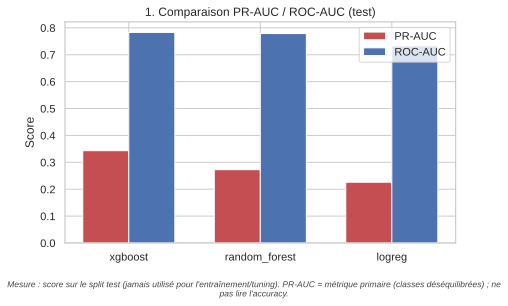

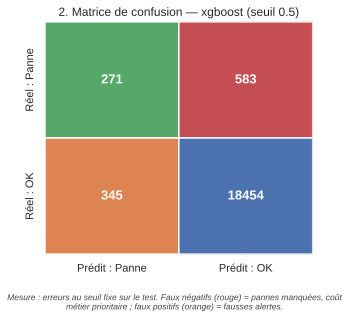

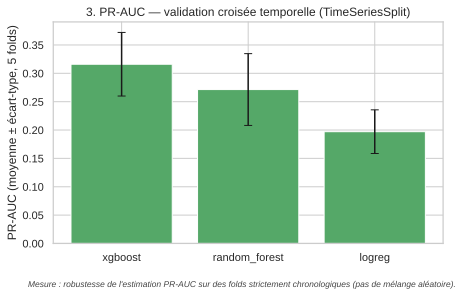

### Horizon 12h — gagnant : **xgboost** (PR-AUC=0.3738, ROC-AUC=0.7419)

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,xgboost,0.373801,0.741903,0.334030,0.054340,0.440256,0.364976,0.399097,17170,787,1077,619
1,random_forest,0.320671,0.756936,0.311270,0.062313,0.687500,0.084316,0.150210,17892,65,1553,143
2,logreg,0.315417,0.728697,0.256477,0.048974,0.159013,0.653302,0.255771,12097,5860,588,1108


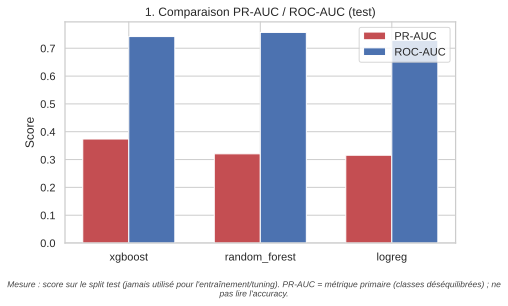

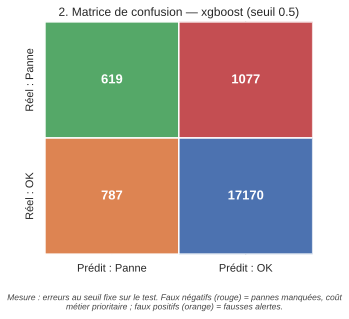

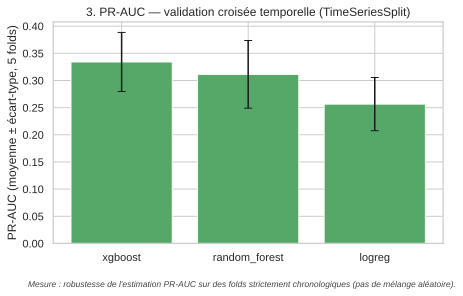

### Horizon 24h — gagnant : **xgboost** (PR-AUC=0.4495, ROC-AUC=0.7098)

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,xgboost,0.449497,0.709803,0.393020,0.041143,0.449093,0.389477,0.417166,14766,1580,2019,1288
1,logreg,0.428257,0.716126,0.353781,0.053192,0.269401,0.661324,0.382845,10415,5931,1120,2187
2,random_forest,0.422528,0.739065,0.401541,0.040938,0.673333,0.213789,0.324535,16003,343,2600,707


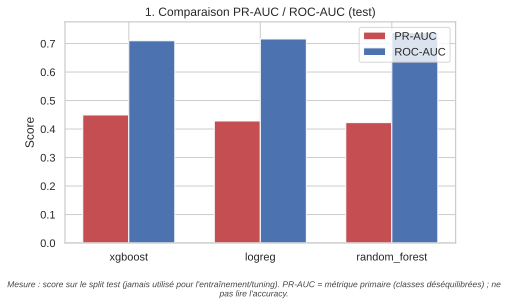

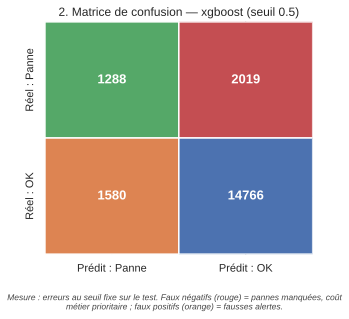

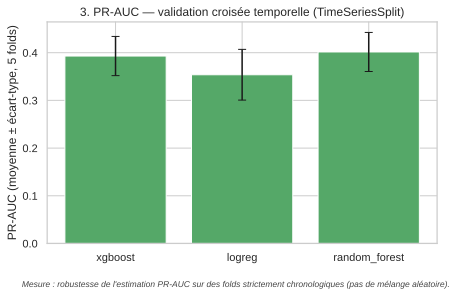

### Horizon 48h — gagnant : **logreg** (PR-AUC=0.4495, ROC-AUC=0.6593)

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,logreg,0.449499,0.659324,0.389340,0.033616,0.336543,0.598630,0.430861,8833,5857,1992,2971
1,xgboost,0.436614,0.635510,0.378455,0.050963,0.415385,0.380818,0.397351,12030,2660,3073,1890
2,random_forest,0.430954,0.676649,0.389331,0.056322,0.539338,0.200282,0.292095,13841,849,3969,994


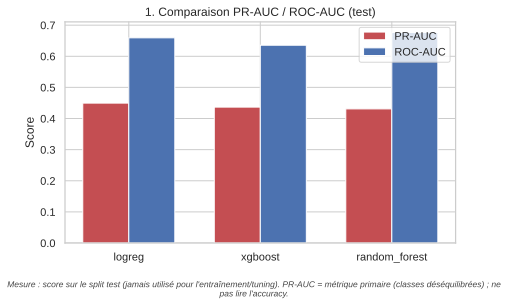

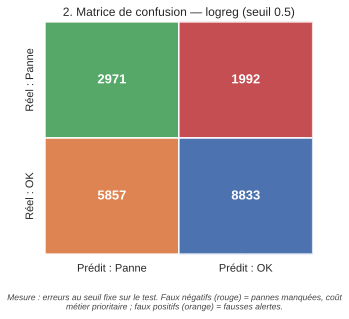

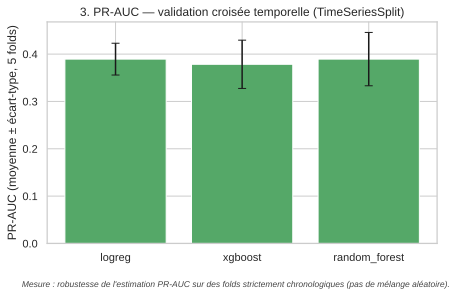

In [3]:
from pathlib import Path

from IPython.display import SVG, Markdown, display

for h in config.LABEL_HORIZONS:
    meta = runs_by_horizon[h]
    display(Markdown(
        f"### Horizon {h}h — gagnant : **{meta['winner']}** "
        f"(PR-AUC={meta['pr_auc_test']}, ROC-AUC={meta['roc_auc_test']})"
    ))
    display(pd.DataFrame(meta["comparison"]))
    run_dir = Path(meta["chemin"])
    for fig in sorted((run_dir / "figures").glob("*.svg")):
        display(SVG(filename=str(fig)))

## 4. MLflow

Chaque modèle, pour chaque horizon (12 runs au total : 4 horizons × 3 modèles), est loggé
(params dont `horizon`, métriques, figure de confusion, pipeline) dans la même expérience
MLflow locale (backend SQLite, `artifacts/ml/mlflow.db`, non versionné) — filtrable par le
paramètre `horizon` dans l'UI.

Pour explorer les runs :

```bash
uv run mlflow ui --backend-store-uri sqlite:///artifacts/ml/mlflow.db
```

## 5. Explication des métriques

> Double lecture pour chaque métrique : la **définition technique** (pour un profil IA) et
> ce qu'elle **signifie concrètement pour le métier** (maintenance/production), avec des
> chiffres réels tirés du run 24h/XGBoost (`tn=14766, fp=1580, fn=2019, tp=1288`) à titre
> d'exemple.

### 5.1 Le vocabulaire de base : les 4 issues possibles d'une prédiction

Avant les métriques, la brique élémentaire : à chaque heure, pour chaque machine, le modèle
prédit « Panne » ou « OK », et la réalité tombe ensuite dans l'une de ces 4 cases (seuil de
décision fixé à 0.5, cf. §5.4) :

| Case | Nom technique | Ce qui s'est passé | Coût métier |
|---|---|---|---|
| 🟩 | **TP** — Vrai Positif | Panne prédite, panne réellement survenue | Aucun — c'est l'objectif : intervention planifiée à temps |
| 🟥 | **FN** — Faux Négatif | Panne **non** prédite, mais survenue quand même | **Le plus coûteux** : arrêt de production non planifié, aucune anticipation possible |
| 🟧 | **FP** — Faux Positif | Panne prédite, mais tout allait bien | Coût de vérification/intervention « pour rien » — dérangement, mais pas de casse |
| 🟦 | **TN** — Vrai Négatif | Pas d'alerte, et effectivement rien ne s'est passé | Aucun — fonctionnement normal, correctement identifié |

Sur l'exemple XGBoost/24h : 1288 vraies alertes utiles (TP), 2019 pannes passées sous le
radar (FN), 1580 fausses alertes (FP), 14766 périodes calmes bien identifiées (TN) —
soit 19653 heures-machine de test au total.

### 5.2 Métriques de score global (indépendantes du seuil de décision)

Ces métriques évaluent la **qualité du classement des probabilités** produites par le
modèle, avant même de fixer un seuil pour décider « panne » ou « OK ». Elles ne bougent pas
si on change le seuil 0.5 en B7.

| Colonne | Définition technique | Pour le métier |
|---|---|---|
| `pr_auc_test` | **PR-AUC** (*Average Precision*) : aire sous la courbe Précision–Rappel, obtenue en faisant varier le seuil de 0 à 1 sur les probabilités prédites. Un classifieur aléatoire obtient une PR-AUC ≈ au taux de positifs réels (≈ 0,163 à 24h) ; un classifieur parfait obtient 1,0. **Métrique primaire** de ce projet car robuste au déséquilibre de classes (contrairement à l'accuracy, qui resterait artificiellement haute même pour un modèle qui ne détecte jamais rien). | « Sur 100 alertes que le modèle pourrait émettre en les classant de la plus urgente à la moins urgente, combien, en moyenne, sont de vraies pannes ? » Plus c'est haut, mieux le modèle **hiérarchise** les cas à risque en tête de liste. Une valeur de 0,45 à 24h signifie qu'on est ~2,8× meilleur qu'un tirage au hasard (0,163) — un vrai gain, mais loin d'un système infaillible. |
| `roc_auc_test` | **ROC-AUC** : aire sous la courbe Rappel vs Taux de faux positifs. Interprétation probabiliste : probabilité que le modèle attribue un score de risque plus élevé à une machine tirée au hasard parmi celles qui vont tomber en panne qu'à une machine tirée au hasard parmi celles qui vont bien. Va de 0,5 (aléatoire) à 1,0 (parfait) — **indépendante du taux de positifs**, contrairement à la PR-AUC, donc comparable d'un horizon à l'autre. Métrique **secondaire** ici : elle peut paraître optimiste sur des classes très déséquilibrées. | « Si je prends une machine qui va vraiment tomber en panne et une machine qui va bien, dans quelle proportion des cas le modèle donne-t-il un score de risque plus élevé à la bonne ? » 0,71 à 24h ≈ « le modèle a raison 71 fois sur 100 dans ce genre de comparaison ». |
| `pr_auc_cv_mean` / `pr_auc_cv_std` | Moyenne et écart-type de la PR-AUC recalculée sur 5 découpages temporels successifs (`TimeSeriesSplit`, jeu complet retrié par horodatage), chaque fold ré-entraînant le pipeline de zéro sur sa portion « passé ». Mesure la **stabilité** du score au-delà d'une seule mesure sur le split test. | « Le chiffre `pr_auc_test` ci-dessus n'est mesuré qu'une fois, sur une seule période récente. Est-ce un coup de chance ou un résultat qui se répète ? » On répète la mesure 5 fois sur 5 périodes différentes : une moyenne proche de `pr_auc_test` et un écart-type faible veulent dire que le résultat est **fiable et reproductible**, pas un hasard de calendrier. |

### 5.3 Métriques au seuil de décision fixe (0.5)

Celles-ci dépendent directement de la règle « si probabilité ≥ 0.5 alors on prédit Panne » —
elles **changeraient** si le seuil était réglé différemment (travail prévu en B7).

| Colonne | Définition technique | Pour le métier |
|---|---|---|
| `precision` | `TP / (TP + FP)`. Parmi les cas où le modèle a prédit « Panne », proportion où c'était vrai. | « Sur 100 alertes envoyées à l'équipe de maintenance, combien correspondent à une vraie panne à venir, et combien sont des dérangements pour rien ? » 0,45 à 24h (XGBoost) = **45 alertes vraies pour 55 fausses** sur 100 alertes émises — c'est le prix (en dérangements) de la couverture obtenue. |
| `recall` | `TP / (TP + FN)`. Parmi les pannes réellement survenues, proportion détectée à l'avance par le modèle. | « Sur 100 pannes qui vont vraiment arriver, combien le modèle a-t-il vu venir ? » 0,39 à 24h = **39 pannes anticipées sur 100** ; les 61 restantes surviennent sans alerte préalable — c'est **le chiffre le plus critique pour le métier** (cf. `reports/cadrage.md` §5 : une panne manquée coûte structurellement plus cher qu'une fausse alerte). |
| `f1` | Moyenne harmonique de precision et recall : `2·P·R / (P+R)`. Résume les deux en un seul nombre, mais **masque lequel des deux domine**. | Utile pour un classement rapide entre modèles, mais **jamais à lire seul** ici : deux modèles avec le même F1 peuvent avoir des profils opposés (ex. Random Forest à 24h : precision 0,67/recall 0,21 — très peu de fausses alertes mais beaucoup de pannes manquées — contre LogReg : precision 0,27/recall 0,66 — l'inverse). Le bon compromis dépend du coût réel, fixé avec le métier, pas d'un F1 abstrait. |
| `tn`, `fp`, `fn`, `tp` | Les 4 comptages bruts de la matrice de confusion (§5.1), au seuil 0.5. | Ce sont les **volumes réels** derrière les pourcentages précédents — utile pour chiffrer un coût (ex. « 2019 pannes manquées sur la période de test » à traduire en heures d'arrêt non planifié). |

### 5.4 Colonnes de contexte (comparaison multi-horizons)

| Colonne | Définition technique | Pour le métier |
|---|---|---|
| `horizon_h` | Fenêtre du label prédit : « panne dans les H heures qui suivent » (`label_incident_{H}h`, cf. `src/indusense/data/gold.py`). Le taux de positifs réels croît avec H (4,3 % à 6h → 25,1 % à 48h, cf. `reports/datasheet.md`), ce qui explique pourquoi la PR-AUC (sensible au taux de base) et la ROC-AUC (insensible) évoluent en sens inverse d'un horizon à l'autre. | « À combien de temps à l'avance veut-on être prévenu ? » Horizon court (6h) = alerte plus tardive mais plus fiable question timing (ROC-AUC plus élevé, signal plus net) ; horizon long (48h) = plus de temps pour s'organiser, mais un signal précurseur plus flou et plus de « bruit » à trier. |
| `run_id` | Identifiant du run (`AAAAMMJJHHMM`) : pointe vers `artifacts/ml/<run_id>/` (figures, `run_metadata.json`, `comparaison.csv`) et vers les runs MLflow correspondants — traçabilité technique. | Pas d'impact métier direct ; permet de retrouver l'expérience exacte derrière un chiffre cité dans un rapport. |
| `temps_entrainement_s` | Temps mur (`time.perf_counter`) de `training.run(horizon=h)` : 3 pipelines fittés une fois sur train + 5 refits chacun pour la validation croisée + logging MLflow — pas seulement le `.fit()` final. | Temps machine nécessaire pour **ré-entraîner** le modèle quand de nouvelles données arrivent (quelques minutes ici) — sans rapport avec le temps de **prédiction** en production, qui est quasi instantané une fois le modèle entraîné. |

### 5.5 Paramètres fixés pour ce POC (B5)

| Paramètre | Valeur | Pour le métier |
|---|---|---|
| Seuil de décision | `0.5` (`config.ML_DECISION_THRESHOLD`) | C'est le curseur qui arbitre entre **moins de pannes manquées** (recall ↑) et **moins de fausses alertes** (precision ↑) — actuellement fixé arbitrairement à 0,5 par défaut. Le régler finement nécessite de chiffrer, avec le métier, le coût réel d'une panne manquée vs celui d'une fausse alerte : c'est le travail prévu en **B7**. |
| Nombre de folds CV | `5` (`time_series_cv(..., n_splits=5)`) | Nombre de périodes de test utilisées pour vérifier la robustesse du score (§5.2) — plus il y en a, plus la vérification est fiable, au prix d'un temps d'entraînement plus long. |
| Split train/val/test | Chronologique, existant (`split`), jamais aléatoire | Le modèle est entraîné sur le **passé** et évalué sur une période **plus récente qu'il n'a jamais vue** — comme en production réelle, où le modèle ne peut jamais s'appuyer sur des données du futur pour prédire le présent.

➡️ **Conclusions**

- **Le gagnant change avec l'horizon** : XGBoost l'emporte à 6h/12h/24h (PR-AUC 0,343 → 0,374
  → 0,450), mais c'est la **régression logistique** qui prend la tête à 48h (PR-AUC 0,4495 —
  quasi identique aux 4 décimales à celle d'XGBoost à 24h, 0,4495 aussi) avec un **rappel**
  bien supérieur (0,60 contre 0,38 pour XGBoost à 48h) au prix d'une precision plus faible
  (0,34 contre 0,42). Le modèle à retenir pour B7 dépend donc de l'horizon opérationnel visé,
  pas d'un choix unique et définitif.
- **PR-AUC monte avec l'horizon (0,343 → 0,450), ROC-AUC descend (0,783 → 0,659)** : les deux
  métriques racontent des histoires différentes. La PR-AUC profite mécaniquement du taux de
  positifs croissant (4,3 % à 6h → 25,1 % à 48h, cf. `reports/datasheet.md`) ; le ROC-AUC,
  invariant à ce taux, montre que le signal précurseur est en réalité **plus net à court
  terme** (6h) qu'à long terme (48h) — cohérent avec l'intuition métier (une panne imminente
  laisse des traces plus franches qu'une dérive amorcée 2 jours à l'avance).
- **Random Forest est le point faible à seuil fixe (0.5)**, sur les 4 horizons : rappel très
  faible (3 % à 6h, 8 % à 12h, 21 % à 24h, 20 % à 48h) malgré un ROC-AUC comparable aux
  autres modèles — `class_weight="balanced"` ne suffit pas à faire dépasser 0.5 aux
  probabilités qu'il attribue à la classe rare. Signal fort que **le choix du seuil (B7)**
  compte au moins autant que le choix du modèle pour ce cas d'usage.
- **Temps d'entraînement stable** (≈260-345 s par horizon, 3 modèles + CV 5 folds + logging
  MLflow) : pas de dérive notable avec l'horizon, la volumétrie de features étant identique
  (seul le label change) — le coût dominant est XGBoost/Random Forest (300 arbres) plutôt que
  l'effet du déséquilibre de classe.
- **Lecture métier** (faux négatifs = pannes manquées, coût prioritaire, cf.
  `reports/cadrage.md` §5) : à seuil fixe, XGBoost (6h/12h/24h) et la régression logistique
  (48h) restent les compromis precision/rappel les plus exploitables ; Random Forest, malgré
  un bon ROC-AUC, n'est pas utilisable tel quel sans recalibrage de seuil.
- **Anti-fuite inchangé sur les 4 horizons** : imputation médiane fit-train (referme le
  correctif silver), RUL et les 3 autres horizons exclus des features à chaque itération,
  split chronologique respecté, validation croisée strictement temporelle.
- **Renvoyé à B7** : optimisation des hyperparamètres **et du seuil de décision par
  horizon** — le seuil fixe 0.5 masque une partie du potentiel de Random Forest et rend la
  comparaison entre modèles moins équitable qu'elle ne pourrait l'être.

## 6. Exploration du seuil de décision (aperçu B7)

Cette section **n'entraîne rien de nouveau côté B5** : le seuil fixe 0.5 utilisé dans le
tableau comparatif et la matrice de confusion de la section 3 reste inchangé. Elle explore,
pour le modèle **gagnant de chaque horizon**, ce que donnerait un seuil différent — en ne
refittant que ce modèle (`training.fit_winner_pipeline`, sans validation croisée) puis en
balayant tous les seuils possibles via la courbe précision/rappel
(`training.precision_recall_curve_data`).

Deux seuils "optimaux" sont repérés à titre indicatif :
- **Optimal F1** : maximise la moyenne harmonique précision/rappel (compromis neutre).
- **Optimal F2** : pondère le rappel deux fois plus que la précision — cohérent avec le coût
  métier asymétrique documenté dans `reports/cadrage.md` (une panne manquée coûte
  structurellement plus cher qu'une fausse alerte).

Aucun de ces seuils n'est adopté ici : le choix définitif (et sa justification chiffrée avec
le métier) est renvoyé au module **B7**.

### Horizon 6h — gagnant : **xgboost**

,seuil,valeur_seuil,precision,recall,f1,tn,fp,fn,tp
0,Seuil actuel (B5),0.500,0.440,0.317,0.369,18454,345,583,271
1,Optimal F1,0.487,0.434,0.324,0.371,18438,361,577,277
2,Optimal F2,0.218,0.218,0.471,0.298,17360,1439,452,402


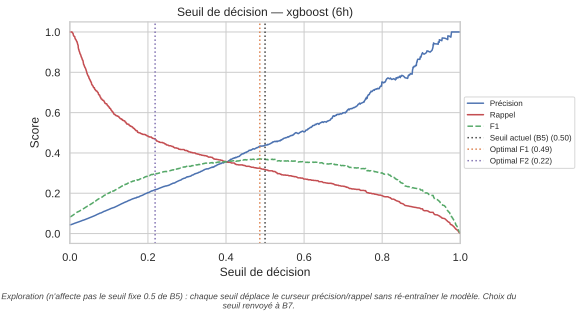

### Horizon 12h — gagnant : **xgboost**

,seuil,valeur_seuil,precision,recall,f1,tn,fp,fn,tp
0,Seuil actuel (B5),0.500,0.440,0.365,0.399,17170,787,1077,619
1,Optimal F1,0.482,0.426,0.377,0.400,17094,863,1056,640
2,Optimal F2,0.235,0.232,0.540,0.325,14929,3028,780,916


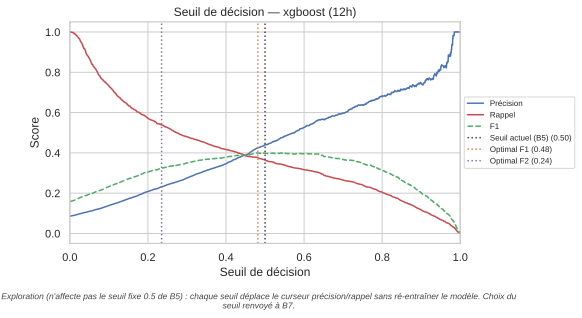

### Horizon 24h — gagnant : **xgboost**

,seuil,valeur_seuil,precision,recall,f1,tn,fp,fn,tp
0,Seuil actuel (B5),0.500,0.449,0.389,0.417,14766,1580,2019,1288
1,Optimal F1,0.462,0.428,0.415,0.421,14514,1832,1935,1372
2,Optimal F2,0.053,0.193,0.916,0.319,3669,12677,278,3029


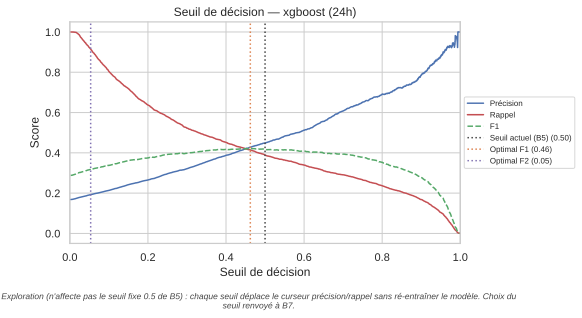

### Horizon 48h — gagnant : **logreg**

,seuil,valeur_seuil,precision,recall,f1,tn,fp,fn,tp
0,Seuil actuel (B5),0.500,0.337,0.599,0.431,8833,5857,1992,2971
1,Optimal F1,0.411,0.305,0.811,0.444,5534,9156,939,4024
2,Optimal F2,0.333,0.284,0.925,0.434,3102,11588,370,4593


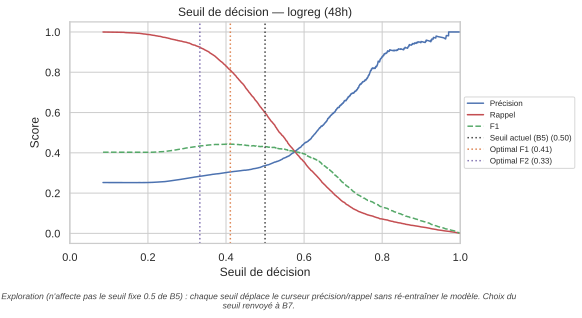

In [4]:
from IPython.display import SVG, Markdown, display

threshold_dir = config.ML_DIR / "threshold_exploration"
threshold_dir.mkdir(parents=True, exist_ok=True)

threshold_rows = []
for h in config.LABEL_HORIZONS:
    winner = runs_by_horizon[h]["winner"]
    pipeline, X_test, y_test = training.fit_winner_pipeline(h, winner)
    proba = pipeline.predict_proba(X_test)[:, 1]
    pr_df = training.precision_recall_curve_data(y_test, proba)
    best_f1 = training.best_threshold(pr_df, "f1")
    best_f2 = training.best_threshold(pr_df, "f2")

    marks = {
        "Seuil actuel (B5)": config.ML_DECISION_THRESHOLD,
        "Optimal F1": best_f1,
        "Optimal F2": best_f2,
    }
    fig_path = threshold_dir / f"seuil_{h}h.svg"
    training.make_threshold_figure(
        pr_df, marks, fig_path, f"Seuil de décision — {winner} ({h}h)"
    )

    display(Markdown(f"### Horizon {h}h — gagnant : **{winner}**"))
    for label, t in marks.items():
        m = training.evaluate(pipeline, X_test, y_test, threshold=t)
        threshold_rows.append({
            "horizon_h": h, "modele": winner, "seuil": label, "valeur_seuil": round(t, 3),
            "precision": round(m["precision"], 3), "recall": round(m["recall"], 3),
            "f1": round(m["f1"], 3),
            "tn": m["tn"], "fp": m["fp"], "fn": m["fn"], "tp": m["tp"],
        })
    display(pd.DataFrame(threshold_rows[-3:]).drop(columns=["horizon_h", "modele"]))
    display(SVG(filename=str(fig_path)))

threshold_table = pd.DataFrame(threshold_rows)

**Synthèse de l'exploration**

- **XGBoost (6h/12h/24h) : l'optimum F1 est proche du seuil actuel.** Le seuil qui maximise F1
  reste voisin de 0.5 (0.487 à 6h, 0.482 à 12h, 0.462 à 24h) pour un gain marginal
  (F1 +0,002 à +0,004) — optimiser F1 seul n'aurait presque rien changé pour ce modèle.
- **... mais l'optimum F2 est extrême et opérationnellement inutilisable.** Pour XGBoost, viser
  un F2 maximal fait chuter le seuil très bas (0.218 à 6h/12h, **0.053 à 24h**) : à 24h, le
  rappel grimpe à 0,92 mais la précision s'effondre à 0,19 (12 677 fausses alertes contre
  1 580 au seuil actuel) — revient à alerter sur la quasi-totalité du test. Un rappel élevé
  ne vaut rien si l'équipe de maintenance ne peut pas absorber le volume d'alertes généré.
- **Régression logistique (48h) : le seuil change vraiment la donne.** Le seuil optimal F1
  (0.411, contre 0.5) fait passer le rappel de 0,60 à **0,81** pour un coût de précision
  mesuré (0,337 → 0,305) — et améliore aussi le F1 (0,431 → 0,444). Contrairement à XGBoost,
  ce modèle offre un compromis exploitable sur toute une plage de seuils, pas seulement à ses
  deux extrêmes.
- **Interprétation** : l'effet du seuil dépend fortement de la façon dont chaque modèle répartit
  ses probabilités prédites, pas seulement de la métrique visée — un signe que XGBoost/Random
  Forest (déséquilibre géré par pondération) mériteraient une **calibration des probabilités**
  (ex. `CalibratedClassifierCV`) avant qu'un simple déplacement de seuil soit pleinement
  exploitable. Confirme que B7 doit combiner **seuil ET calibration**, choisis sur un vrai
  ratio de coût métier (panne manquée vs fausse alerte) — jamais en maximisant F1/F2 à
  l'aveugle, comme le montre le cas F2/24h ci-dessus.